In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('sales_dataset_100_records.xlsx')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      100 non-null    object 
 1   Product   100 non-null    object 
 2   Category  100 non-null    object 
 3   Region    100 non-null    object 
 4   Sales     100 non-null    int64  
 5   Quantity  100 non-null    int64  
 6   Profit    100 non-null    float64
dtypes: float64(1), int64(2), object(4)
memory usage: 5.6+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.fillna(0,inplace=True)

#PANDAS DATA ANALYSIS

###Find Total Sales

In [6]:
df['Sales'].sum()

np.int64(270044)

###Find Total Profit

In [7]:
df['Profit'].sum()

np.float64(51860.21000000001)

###Find Total Quantity Sold

In [8]:
df['Quantity'].sum()

np.int64(1104)

###Find the highest-selling product

In [9]:
df.value_counts('Product').nlargest(1)

,count
Product,
Desk,19


###Lowest-selling product find karo.

In [10]:
df.value_counts('Product').nsmallest(1)

,count
Product,
Pen,6


##Sales by category (or Category-wise sales)

In [11]:
(df.groupby('Category')['Sales'].sum()).sort_values()

,Sales
Category,
Accessories,37361
Stationery,65700
Furniture,71275
Electronics,95708


###Sales by region (or Region-wise sales)

In [12]:
df.groupby('Region')['Sales'].sum()

,Sales
Region,
East,48575
North,88738
South,50859
West,81872


###Profit by category (or Category-wise profit)

In [13]:
df.groupby('Category')['Profit'].sum()

,Profit
Category,
Accessories,7105.06
Electronics,18933.72
Furniture,13163.37
Stationery,12658.06


###Profit by region (or Region-wise profit)

In [14]:
df.groupby('Region')['Profit'].sum()

,Profit
Region,
East,9108.88
North,20049.80
South,8972.59
West,13728.94


###Top 5 products by sales

In [15]:
(df.groupby('Product')['Sales'].sum()).nlargest(5)

,Sales
Product,
Notebook,51294
Desk,46403
Bottle,37361
Mouse,33256
Laptop,32875


###Monthly sales (or Sales by month)

In [16]:
df['Date'] = pd.to_datetime(df['Date'])
(df.groupby(df['Date'].dt.month_name())['Sales'].sum())


,Sales
Date,
April,20379
August,15352
December,31626
February,30601
January,16678
July,36031
June,30114
March,16793
May,28700


###Monthly profit (or Profit by month)

In [17]:
df.groupby(df['Date'].dt.month_name())['Profit'].sum()

,Profit
Date,
April,3609.83
August,3217.47
December,5975.77
February,5696.23
January,3141.50
July,7112.11
June,5911.18
March,3944.06
May,4714.86


#DATA VISUALIZATION

###Category-wise sales → Bar

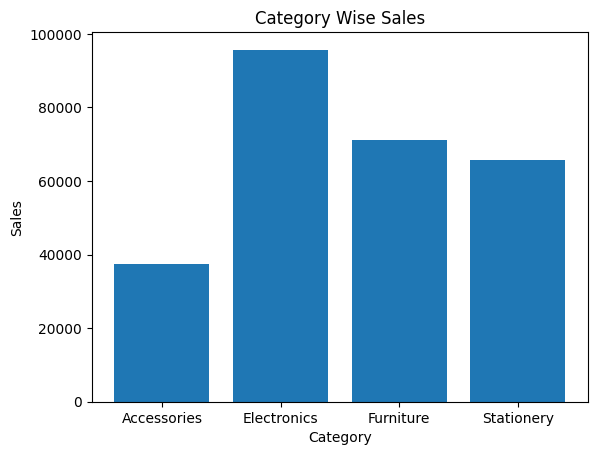

In [18]:
plt.bar((df.groupby('Category')['Sales'].sum()).index,(df.groupby('Category')['Sales'].sum()).values)
plt.title('Category Wise Sales')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

###Region-wise sales → Bar

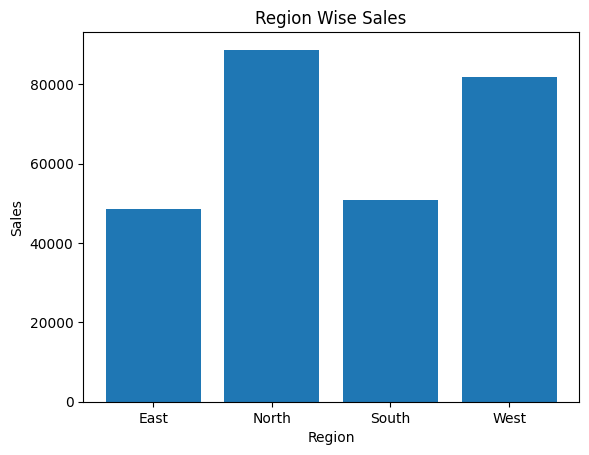

In [19]:
plt.bar((df.groupby('Region')['Sales'].sum()).index,(df.groupby('Region')['Sales'].sum()).values)
plt.title("Region Wise Sales")
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

###Monthly sales → Line

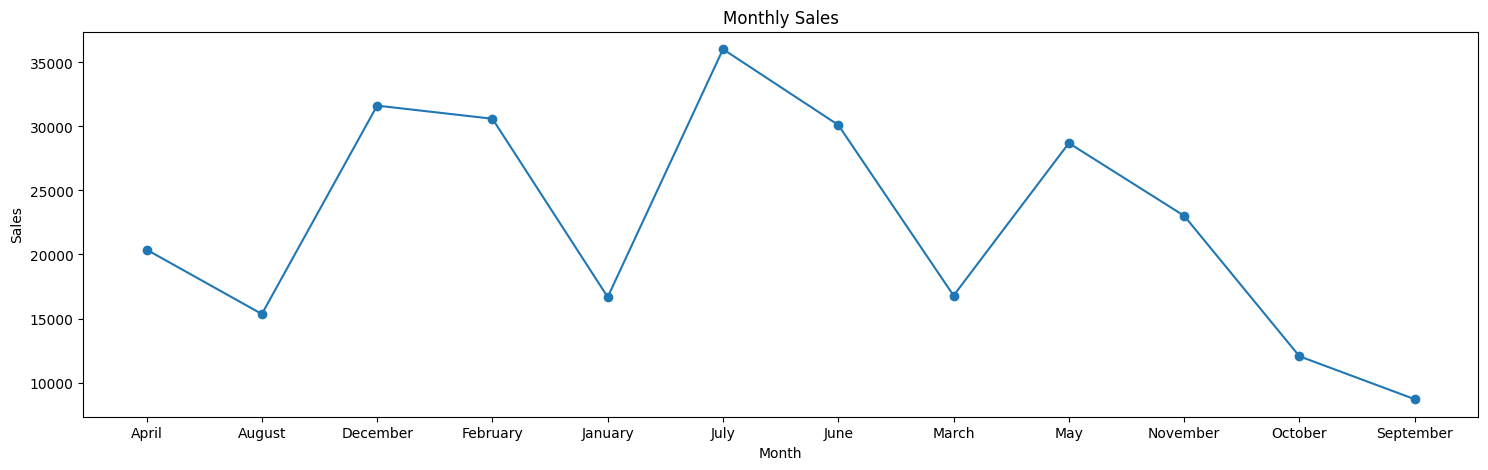

In [20]:
plt.figure(figsize=(18,5))
plt.plot((df.groupby(df['Date'].dt.month_name())['Sales'].sum()).index,(df.groupby(df['Date'].dt.month_name())['Sales'].sum()).values,marker='o')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

###Product-wise sales → Bar

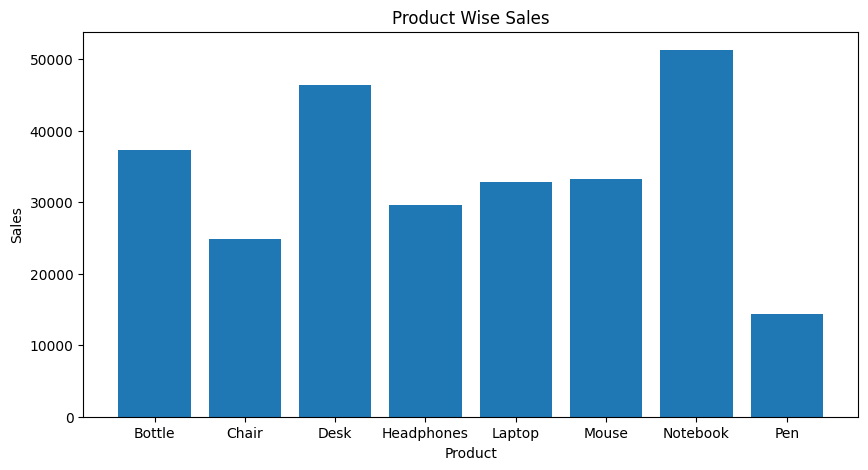

In [21]:
plt.figure(figsize=(10,5))
plt.bar((df.groupby('Product')['Sales'].sum()).index,(df.groupby('Product')['Sales'].sum()).values)
plt.title('Product Wise Sales')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.show()

###Sales vs Profit → Scatter

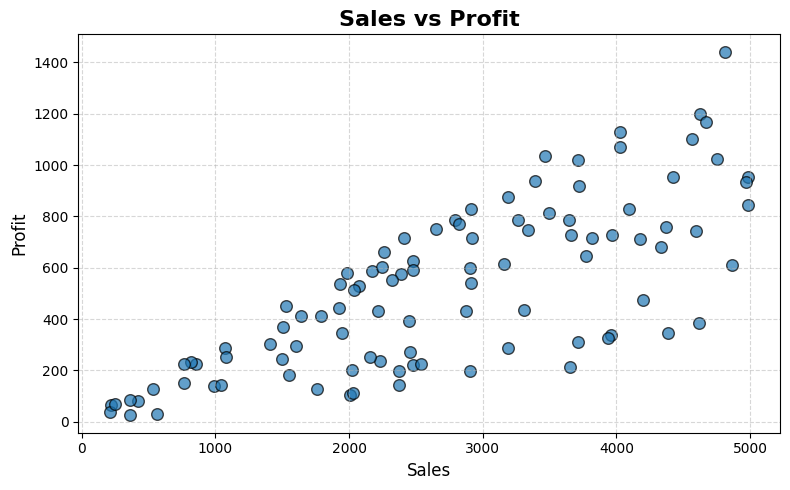

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Sales'],
    df['Profit'],
    s=70,
    alpha=0.7,
    marker='o',
    edgecolors='black'
)

plt.title('Sales vs Profit', fontsize=16, fontweight='bold')
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Profit', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

###Category sales share → Pie

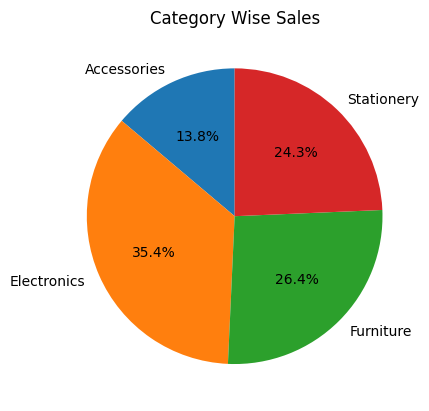

In [22]:
plt.pie((df.groupby('Category')['Sales'].sum()).values,labels=(df.groupby('Category')['Sales'].sum()).index,autopct='%1.1f%%',startangle=90)
plt.title('Category Wise Sales')
plt.show()

###Sales distribution → Histogram

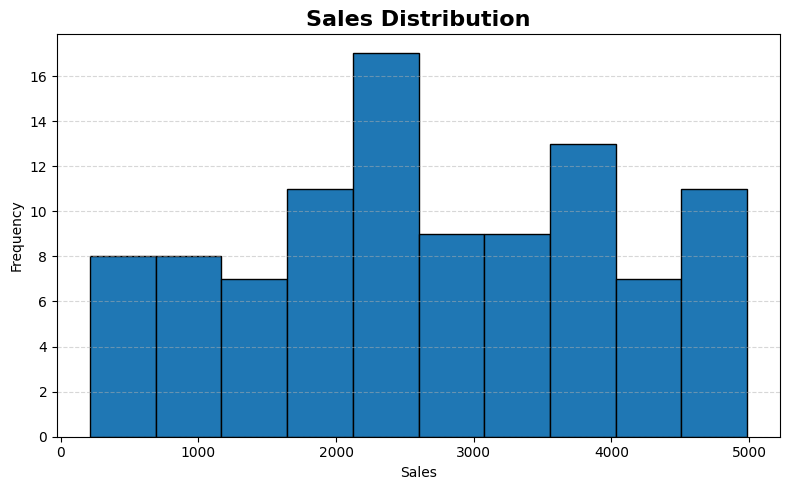

In [26]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Sales'],
    bins=10,
    edgecolor='black'
)

plt.title('Sales Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()